<a href="https://colab.research.google.com/github/Joeaviator/VISUALIZATION_EXTRAS/blob/main/VISUALIZATION_EXTRAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
file = files.upload()

Saving gapminder(2007).csv to gapminder(2007).csv


In [4]:
df=pd.read_csv('gapminder(2007).csv')
df.head()

,Unnamed: 0,country,year,population,continent,life_exp,gdp_cap
0,11,Afghanistan,2007,31889923,Asia,43.828,974.580338
1,23,Albania,2007,3600523,Europe,76.423,5937.029526
2,35,Algeria,2007,33333216,Africa,72.301,6223.367465
3,47,Angola,2007,12420476,Africa,42.731,4797.231267
4,59,Argentina,2007,40301927,Americas,75.320,12779.379640


/tmp/ipykernel_6158/3382432224.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='gdp_cap',y='life_exp',data=df, palette="rainbow")


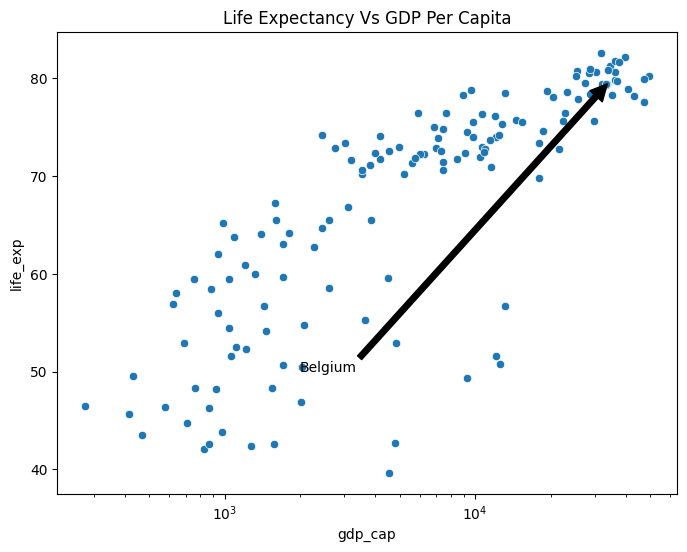

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='gdp_cap',y='life_exp',data=df, palette="rainbow")
#Annotate Belgium
BD=df[df['country']=='Belgium']
plt.annotate('Belgium',xy=(BD["gdp_cap"].values[0],BD["life_exp"].values[0]), xytext=(2000,50),arrowprops=dict(facecolor='black'))
plt.xscale('log')
plt.title('Life Expectancy Vs GDP Per Capita')
plt.show()

/tmp/ipykernel_6158/2996087421.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(
/tmp/ipykernel_6158/2996087421.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


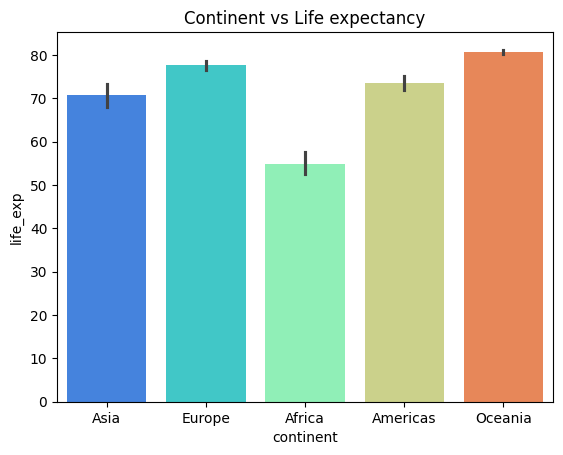

In [9]:
#Confdence
sns.barplot(
    x='continent',
    y='life_exp',
    data=df,
    ci=95, #Confidence Interval
    palette='rainbow'
)
plt.title("Continent vs Life expectancy")
plt.show()

In [14]:
#bokeh to plot
from bokeh.plotting import figure,show
from bokeh.models import ColumnDataSource
source=ColumnDataSource(df)
p=figure(title="Life_exp vs Gdp_cap",x_axis_type='log',x_axis_label='gdp_cap', y_axis_label='life_exp')
p.scatter('gdp_cap','life_exp',source=source,size=8)
show(p)

In [17]:
#plotly
import plotly.express as px
fg=px.scatter(
    df,
    x='gdp_cap',
    y='life_exp',
    color='continent',
    hover_name='country',
    log_x=True,
    title="Life expectancy vs gdp_cap"
)
fg.show()

In [19]:
grouped_data=df.groupby('country')['population'].mean().reset_index().head()
fig=px.bar(
    grouped_data,
    x='country',
    y='population',
    color='country',
    hover_name='country',
    title='Population of Countries'

)
fig.show()